<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/project/Project_3/AgenTekki_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 AgenTekki — Tax Agent Filler

### It's finally here 🥳

Over the past weeks you've seen what agents can do: automated meeting task assigner that never forgets a follow-up, a fashion magazine editor with an eye for detail, a fridge chef that turns leftovers into dinner, and a city lens that sees the restaurants around you. Those were the appetizers!

**This is the main course.** Your first fully dedicated agentic project 💻

---

### What you will build

You are going to build an AI agent that autonomously fills out a Swiss tax return  end to end without hardcoded answers. The agent reads documents, reasons about Swiss tax law, navigates a real web form, and submits a completed declaration.

Along the way you will get hands-on experience with two of the most important patterns in modern AI engineering:

- 🔧 **Tool use**  giving an LLM the ability to interact with the world: read files, click buttons, fill fields, submit forms.
- 🧠 **Step-by-step reasoning**  watching a model think through a problem one action at a time, building on what it already knows.

---

### Two approaches, one goal

You will implement the agent in two ways:

**Hybrid (mandatory)** your code drives the navigation, the LLM reasons about what to fill. Clean, efficient, and how most production AI applications are actually built.

**Fully agentic (bonus)**  the LLM takes the wheel completely. It decides which tools to call, in what order, and when it's done.

---

Happy coding 🚀

## ⚙️ Setup

In [1]:
#@title 📦 Clone Repository (click ▶ to run)

import os
os.chdir("/content")  # reset working directory

!rm -rf /content/project3-agentic-tax-filler
!git clone -b notebook_carlos_prompts https://github.com/eth-bmai-fs26/project3-agentic-tax-filler.git /content/project3-agentic-tax-filler

import sys
# purge any previously imported mcp_server modules from cache
for mod_name in list(sys.modules):
    if mod_name.startswith("mcp_server"):
        del sys.modules[mod_name]

if "/content/project3-agentic-tax-filler" not in sys.path:
    sys.path.insert(0, "/content/project3-agentic-tax-filler")

print("✅ Repo cloned and ready!")

Cloning into '/content/project3-agentic-tax-filler'...
remote: Enumerating objects: 830, done.
remote: Counting objects: 100% (461/461), done.
remote: Compressing objects: 100% (335/335), done.
remote: Total 830 (delta 204), reused 357 (delta 116), pack-reused 369 (from 1)
Receiving objects: 100% (830/830), 5.15 MiB | 9.51 MiB/s, done.
Resolving deltas: 100% (375/375), done.
✅ Repo cloned and ready!


In [2]:
#@title 🏗️ Build & Serve React UI (click ▶ to run)

import subprocess, os, threading, http.server, functools, socket

FRONTEND_DIR = "/content/project3-agentic-tax-filler"
BUILD_DIR    = os.path.join(FRONTEND_DIR, "EnvDemoV1", "dist")

# 1. Make sure the frontend branch is checked out
os.chdir(FRONTEND_DIR)
subprocess.run(["git", "fetch", "origin", "frontend"], check=True)
subprocess.run(["git", "checkout", "frontend"], check=True)

# 2. Install Node dependencies & build
os.chdir(os.path.join(FRONTEND_DIR, "EnvDemoV1"))
subprocess.run(["npm", "install"], check=True)
subprocess.run(["npm", "run", "build"], check=True)

# 3. Find a free port automatically starting from 3000
def find_free_port(start=3000, end=3020):
    for port in range(start, end):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("", port))
                return port
            except OSError:
                print(f"  Port {port} is in use, trying next...")
    raise RuntimeError("No free port found in range!")

PORT = find_free_port()
handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory=BUILD_DIR)
httpd = http.server.HTTPServer(("", PORT), handler)
thread = threading.Thread(target=httpd.serve_forever, daemon=True)
thread.start()

print(f"✅ UI served at http://localhost:{PORT}")

✅ UI served at http://localhost:3000


---
## 🔑 LLM Setup

Configure your LLM provider and paste your API key below.

### Start with ETH Proxy (recommended)

Use the ETH AI Center proxy with `gpt-4o-mini`. This is the fastest way to get started and the model performs very well for this task.
```python
LLM_MODEL   = "gpt-4o-mini"
BASE_URL     = "https://litellm.sph-prod.ethz.ch/v1"  
API_KEY      = "your-key-here"
```

---

### Ran out of quota? Switch to Gemini (free)

If you exhaust your ETH proxy quota, you can use Google Gemini for free. Here's how:

1. Go to [aistudio.google.com](https://aistudio.google.com)
2. Sign in with a Google account
3. Click **Get API key** → **Create API key**
4. Copy the key and paste it below

**Recommended free model:** `gemini-2.0-flash-lite`: 1,500 requests/day, more than enough.
**Better quality:** `gemini-2.5-flash`:  only 20 requests/day, use sparingly.
```python
LLM_MODEL   = "gemini-2.0-flash-lite"
BASE_URL     = "https://generativelanguage.googleapis.com/v1beta/openai/"
API_KEY      = "your-gemini-key-here"
```

> The Gemini endpoint is OpenAI-compatible, so no code changes are needed. Just swap the model, base URL, and key 🎉

In [3]:
import os
import json
from openai import OpenAI

# 🎯 choose your provider: "openai" or "gemini" 🎯
LLM_PROVIDER = "gemini"

if LLM_PROVIDER == "openai":
    # 🎯 paste your ETH proxy key 🎯
    os.environ["OPENAI_API_KEY"] = "xxx"
    client = OpenAI(
        api_key=os.environ["OPENAI_API_KEY"],
        base_url="https://litellm.sph-prod.ethz.ch/v1"  # ETH proxy
    )
    LLM_MODEL = "openai/gpt-4o-mini" #"anthropic/claude-sonnet-4-5"

elif LLM_PROVIDER == "gemini":
    # 🎯 or paste your Gemini API key 🎯
    os.environ["GEMINI_API_KEY"] = "xxx"  # paste your Gemini API key
    client = OpenAI(
        api_key=os.environ["GEMINI_API_KEY"],
        base_url="https://generativelanguage.googleapis.com/v1beta/openai/"  # Gemini OpenAI-compatible endpoint
    )
    LLM_MODEL = "gemini-3.1-flash-lite-preview"#"gemini-2.5-flash"

else:
    raise ValueError(f"Unknown LLM_PROVIDER: {LLM_PROVIDER!r}. Use 'openai' or 'gemini'.")

print(f"Using {LLM_PROVIDER} with model {LLM_MODEL}")


Using gemini with model gemini-3.1-flash-lite-preview


---
## 🔍 Familiarize yourself with the Tax Portal!

> Before building the agent, take a moment to explore the portal manually.
> The cell below renders the UI. Click around and explore!
>
> **Try this:**
> - Navigate through the sections using the sidebar (Personal, Income, Deductions, Wealth)
> - Click into sub-pages using the "Next" button
> - Notice the field types.
> - Try adding rows in Children, Bank Accounts, or Securities (click "+ Add Row")
> - Check the Review page to see how all the data comes together
>
> **Think about:**
> - How would an AI agent know which fields to fill?
> - Where does the data for each field come from (profile, Lohnausweis, bank statement)?
> - Which fields require calculations (e.g., Berufsauslagen = 3% of Nettolohn)?
> - Which fields have caps or thresholds (e.g., Pillar 3a max, KiTa cap, medical 5%)?
>
> When you're ready, move on to the next section where the agent does this automatically.


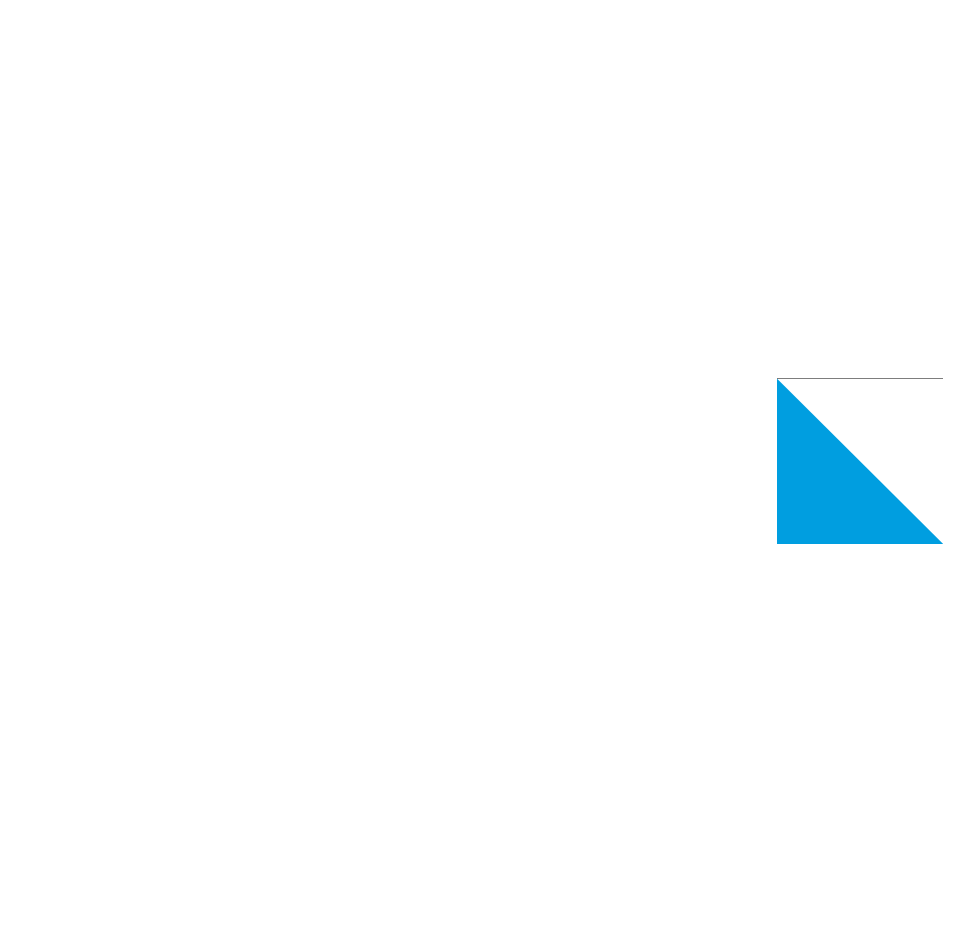

👆 Click around the portal above to explore the form fields.
   Use the sidebar to navigate between sections.
   This is what your agent will need to fill automatically!


In [4]:
# 🔍 Explore the Tax Portal (click around, nothing is saved!)

from IPython.display import display, HTML
import os
from google.colab.output import eval_js
import time


BUILD_DIR = "/content/project3-agentic-tax-filler/EnvDemoV1/dist"
with open(os.path.join(BUILD_DIR, "index.html")) as f:
    html_content = f.read()

html_content = html_content.replace('"/assets/', f'"http://localhost:{PORT}/assets/')
html_content = html_content.replace('"./assets/', f'"http://localhost:{PORT}/assets/')

display(HTML(html_content))
#🎯 fill in your name
name = 'Raphael Fässler & Stefan Sykes'
time.sleep(1)
eval_js(f'window.TaxPortal.setPersona("{name}")')
print("👆 Click around the portal above to explore the form fields.")
print("   Use the sidebar to navigate between sections.")
print("   This is what your agent will need to fill automatically!")

## ✍️ Your Task:  Write the System Prompt!

The `BASE_PROMPT` is very important.
It is the instruction manual your agent reads before touching a single field. The better it is, the higher your score.

---

### What to write

Your prompt needs to cover 4 things:

**1. Role**  Tell the agent who it is. One sentence is enough.

**2. Inputs**  Tell the agent what it will receive. It always gets the same 5 things on every page.

IMPORTANT! After filling the above to the base prompt, please remove the comments ("# 🎯 Describe the agent's role ....", "🎯 Tell the agent what it will ..."). Otherwise, they will be sent to the LLM as literal text!

---

### Example  a good starting point
```
You are an expert Swiss tax accountant AI filling a Zurich tax return.

You will be shown:
1. ALL the taxpayer's documents (pre-read for you)
2. The fields on the CURRENT form page (with their locators, labels, and current values)
3. A history of what you already filled on previous pages
4. RELEVANT TAX GUIDES with the rules and thresholds you need for this page
5. Page-specific instructions for the current section
```

---

### Tips

- Notice that we tell the agent to always consult the tax guides and never guess Swiss tax rules from memory.
- As you move to harder personas, you will come back here and add more rules.
  The `SECTION_PROMPTS` will tell you exactly what to add and where.

In [5]:
# PROMPTS. Iterate on these to improve agent accuracy!
import re
from mcp_server.agent_utils import (
    parse_field_mapping,
    load_all_guides,
    get_guides_for_page,
    PAGE_GUIDE_MAP,
)

# ── load Policy KB from file ──────────────────────────────────
POLICY_KB_PATH = "/content/project3-agentic-tax-filler/guides/policy_kb.txt"
if os.path.exists(POLICY_KB_PATH):
    with open(POLICY_KB_PATH) as f:
        POLICY_KB_TEXT = f.read()
    print(f"✅ Policy KB loaded: {len(POLICY_KB_TEXT)} chars")
else:
    POLICY_KB_TEXT = ""
    print("⚠️ Policy KB not found at", POLICY_KB_PATH)

✅ Policy KB loaded: 2705 chars


In [6]:
# ══════════════════════════════════════════════════════════════════
# ★ SYSTEM PROMPT — The agent's instructions
# ★ Optimized for gemini-3.1-flash-lite-preview
# ══════════════════════════════════════════════════════════════════

# 🎯🎯 ── BASE PROMPT ──────────────────────────────────────────

BASE_PROMPT= ("""
You are an expert Swiss tax filing assistant. Always compute totals from ALL relevant documents (e.g., sum both spouses' Lohnausweise, all Zinsabschluss) before filling any field; cite the exact guide rule or source line in your "thought".

You will receive 5 inputs:
1. The current form page name and section.
2. The list of field locators available on this page with any existing values.
3. The users structured profile data (profile.json).
4. Extracted data from uploaded documents (e.g., Lohnausweis, bank statements).
5. Relevant tax guides and policy rules (Wegleitung / POLICY KB).

Your task: Decide which fields to fill on this page and what values to use. Use TAX GUIDES for ALL thresholds, formulas, and classifications—Do NOT guess from memory.

MANDATORY STEPS BEFORE RESPONDING:
- Scan ALL documents for the section (e.g., sum donations across statements, check every Lohnausweis field).
- For deductions: ALWAYS calculate and fill `weitereberufsauslagen.amount` + `.description` if employment exists (per Pauschale formula); use EXACT recipient names from source for donations (no paraphrasing).
- For banks/wealth: Use EXACT institution name from statement header (no normalization unless guide mandates).
- If married: Sum spouse totals unless form has separate fields; fill partner sections completely or leave empty.
- Return ONLY JSON: { "thought": "reasoning + guide cite", "field-locator": "value", ... } or {} if irrelevant.
- Skip if no data (no 0/empty/placeholders). Do not refil correct existing values. Only use listed locators.

Rules:
- NEVER guess locators, amounts, or names—cite sources.
- Donations → deductions.other only (not gifts).
- Partial/blurry data → conservative cap or skip.
- Always explain thresholds/formulas in "thought" with section cite."""
)

In [7]:
# 🎯🎯 ── SECTION PROMPTS ──────────────────────────────────────────
# Each key corresponds to a form section (personal, income, deductions, wealth, etc.)
# When the agent lands on a page, it looks up the section from the page name
# (e.g., "deductions/professional" → "deductions") and appends the matching prompt to
# the BASE_PROMPT. This way the LLM only sees instructions relevant to the current page.

SECTION_PROMPTS = {

    # ── Yuki Tanaka (Expert) — uncomment when ready ───────────────
    # "personal": """## Personal Details ...
    #   - Filing status after divorce: consult DIVORCE GUIDE for rules and the critical date.
"personal": """## Personal — Fill all fields strictly from sources
- Name, DOB, AHV, address (street, no., zip, city): exact from profile.json/docs
- Marital: single/married/divorced/widowed/separated (profile truth; post-divorce → use DIVORCE GUIDE date)
- Occupation: English, formal; if retired → "Retired (former role)"
- Employer: full exact name (incl. brackets)
- Partner: ALWAYS present → fill ALL if married, else empty
- Children: fill BOTH name AND dateOfBirth. Include "_rows_needed": N if rows need adding.
- Bank: IBAN + institution ONLY if explicitly present (no inference)
- Rule: never partially fill any entity
- _thought: cite exact source/line for every value
""",

    # ── Bernasconi (Medium) — uncomment when ready ────────────────
    # "income": """## Income Section ...
    #   - For married couples: sum both Lohnausweise.
    #   - Dienstaltersgeschenke (field 6) already included in Bruttolohn — do NOT add separately.
    #   - Rental: fill Eigenmietwert from property documents.
    # ── Priya Chakraborty (Hard) — uncomment when ready ──────────
    # "income": """## Income Section ...
    #   - Self-employment: consult FREELANCE GUIDE for revenue, expenses, netincome, AHV threshold.
    #   - Foreign dividends: convert to CHF using ESTV year-end exchange rate.
    #   - Capital gains from private investing are TAX-FREE — do NOT declare as income.
    # ── Thomas & Elisabeth Widmer (Very Hard) — uncomment when ready ──
    # "income": """## Income Section ...
    #   - Retirement: consult RETIREMENT GUIDE for AHV vs BVG pension classification.
    #   - Capital withdrawals go in capitalwithdrawals field — NOT in regular income.
    #   - Freizügigkeitskonto: balance = wealth, interest = income.
    # ── Yuki Tanaka (Expert) — uncomment when ready ───────────────
    # "income": """## Income Section ...
    #   - Alimony: consult DIVORCE GUIDE — spousal support is taxable, child support is NOT.
    # """,
"income": """## Income — Follow guides strictly
- Employment: sum ALL Lohnausweis (Bruttolohn 1, AHV 9, BVG 10); no double-count (e.g. field 6)
- Interest: sum ALL "Zinsabschluss" (CSV)
- Retirement: classify AHV vs BVG per RETIREMENT GUIDE
- Rental: Eigenmietwert (+ costs if applicable) from property docs
- Capital withdrawals: ONLY in capitalwithdrawals (not income)
- Freelance: net (rev−exp); include AHV if above threshold
- Foreign: convert to CHF using ESTV year-end rate
- Alimony: only spousal taxable
- _thought: show sums, conversions, and sources
""",

    # ── Bernasconi (Medium) — uncomment when ready ────────────────
    # "deductions": """## Deductions Section ...
    #   - Verpflegung: calculate EACH spouse separately, then sum. Prorate part-time by Pensum.
    #   - Kinderbetreuungskosten: consult CHILDCARE GUIDE for Zurich cantonal cap and age limits.
    #   - Zweiverdienerabzug: consult POLICY RULES — applies when BOTH spouses are employed.
    #   - Berufsauslagen: calculate per person, show working in _thought.
    # ── Yuki Tanaka (Expert) — uncomment when ready ───────────────
    # "deductions": """## Deductions Section ...
    #   - Alleinerziehenden-Abzug: divorced/single parent with primary custody may qualify.
    #     If no dedicated field exists, add under otherdeductions.
    #   - Kinderbetreuungskosten: if receipt is blurry/partial, apply the cap conservatively.
    # """,
"deductions": """## Deductions — Apply policy rules
- Verpflegung: Lohnausweis 14.1; calculate EACH spouse separately, then sum. Prorate part-time by Pensum
- Berufsauslagen: pauschale (% with min/max) on net income; required field; show working in _thought
- Commuting: include Velo-Pauschale if eligible
- Pillar 3a: cap per person; sum spouses
- Childcare: Zurich cap + age rules; conservative if unclear
- Kinderbetreuungskosten: consult CHILDCARE GUIDE for Zurich cantonal cap and age limits.
- Zweiverdienerabzug: consult POLICY RULES — applies when BOTH spouses are employed.
- Debt interest: sum all mortgages; zero if none
- Donations: exact recipient + amount → other
- Medical: zero if none; else exact from receipts
- Single-parent: only if eligible
- _thought: show formulas, thresholds, sources
""",

    # ── Bernasconi (Medium) — uncomment when ready ────────────────
    # "wealth": """## Wealth Section ...
    #   - Real estate: use Steuerwert from Gemeinde assessment (NOT market value).
    #   - Mortgage balance: declare as debt. Creditor name from property docs.
    # ── Priya Chakraborty (Hard) — uncomment when ready ──────────
    # "wealth": """## Wealth Section ...
    #   - Foreign securities: convert to CHF using ESTV year-end exchange rate.
    #   - Consult VERRECHNUNGSSTEUER GUIDE if Swiss dividends exist — claim the 35% refund.
    # ── Yuki Tanaka (Expert) — uncomment when ready ───────────────
    # "wealth": """## Wealth Section ...
    #   - If property docs are missing but address is known (from divorce decree or bank
    #     statement), fill the address field anyway — partial info is better than nothing.
    #   - If mortgage payments exist but no balance document: leave amount EMPTY.
"wealth": """## Wealth — Declare all assets (year-end)
- Bank: Dec 31 balance (last CSV line); exact name; sum interest; add "_rows_needed": N if needed
- Securities: ISIN, quantity, value, gross return
- Insurance/Freizügigkeit: treat as accounts; include value; interest → income
- Real estate: Steuerwert (not market); full address; mortgages as debt (exact creditor)
- Foreign assets: convert to CHF; handle withholding tax if applicable
- Movables: cash/valuables; zero if none
- _thought: cite source for each value
""",

"attachments": """## Attachments
- Always return {}
""",

"review": """## Review
- Always return {}
""",

}

## 🧠 The `think` Function — How It Works

This is the brain of your agent. It follows a **hybrid approach**: your code drives the navigation, and the LLM decides what to write in each field.

---

### What happens, step by step

**Before the loop:**
1. **Read all documents**:  every file in the persona's folder is loaded into memory upfront
2. **Load tax guides**:  Swiss tax rules and thresholds are loaded for the LLM to consult
3. **Navigate to the form**: the agent clicks into the form automatically

**Inside the `while` loop:  one iteration per page:**

4. **Scan the page**:  the agent looks at what fields are currently on screen
5. **Ask the LLM**: the agent sends the fields + documents + guides to the LLM, which returns a `{locator: value}` mapping
6. **Fill the page**: the agent types each value into the corresponding field
7. **Navigate forward**: the agent clicks `btn-next` and moves to the next page
8. **Repeat** until the review page is reached, then **submit**

---

### Key functions

**`ask_llm_for_page(page_name, fields)`**
Builds a prompt from all documents, tax guides, fill history and the current page's fields (5 igridients), then calls the LLM. Returns a `{locator: value}` dict which is the LLM's answer to *"what should I fill in here?"*

**`fill_page(mapping, page_name)`**
Takes that dict and calls `server.fill_field()` for each entry. Logs what was filled and stores it in `filled_history` so later pages have context.

**`add_rows_if_needed(page_name, elements, n)`**
Some sections (children, bank accounts, securities) start completely empty. No fields appear until you click **+ Add Row**. This helper detects those buttons, counts existing rows, and adds more until there are enough for the LLM to fill.

In [8]:
import json
import time
import re

def think(server, client, system_prompt_ignored=None, max_steps=100):
    """
    ══════════════════════════════════════════════════════════════
                   HYBRID AGENT — YOUR IMPLEMENTATION!
    ══════════════════════════════════════════════════════════════
      Fill in the 🎯 marked lines below

      Tools you will use:
        • server.list_documents()    — list available files
        • server.read_document(path) — read a file's content
        • server.scan_page()         — see what's on screen
        • server.click_element(loc)  — click a button or tab
        • server.fill_field(loc, v)  — type a value into a field
        • server.submit_form()       — submit the final form

      Functions you will use: add_rows_if_needed(page, elements, n)
        ask_llm_for_page(page_name, fields)
    ══════════════════════════════════════════════════════════════
    """

    # ── Logging ──────────────────────────────────────────────────
    log_lines = []
    def log(msg):
        print(msg)
        log_lines.append(msg)

    # ── 1. Pre-read all documents ────────────────────────────────
    log("📂 Pre-reading all documents...")

    # 🎯 List all documents available for this persona 🎯
    #doc_list = ...
    doc_list = server.list_documents()


    all_docs = {}
    for filepath in doc_list:
        # 🎯 Read each document by its filepath 🎯
        #doc = ...
        doc = server.read_document(filepath)
        all_docs[filepath] = doc
        log(f"  📄 {filepath} ({doc['type']}, {len(doc.get('content', ''))} chars)")

    docs_text = "\n\n".join(
        f"=== {name} ===\n{doc['content'][:8000]}"
        for name, doc in all_docs.items()
    )
    log(f"✅ Pre-read {len(all_docs)} documents.\n")

    # ── 2. Pre-load tax guides ──────────────────
    log("📚 Pre-loading tax guides...")
    all_guides = load_all_guides(
        "/content/project3-agentic-tax-filler/guides"
    )
    log(f"✅ Loaded {len(all_guides)} guides: {list(all_guides.keys())}")

    # ── 3. State tracking ─────────────────────────────────────────
    filled_history = {}   # {page_name: {locator: value, ...}}
    llm_calls = 0
    total_fields_filled = 0

    # ── 4. Auto-navigate to the first form page ──────────────────
    # 🎯 Scan the current page to see where we are 🎯
    #initial = ...
    initial = server.scan_page()
    page_name = initial.get("page_name", "")
    if not initial.get("elements") or page_name in ("root", "overview", ""):
        log("⚡ Auto-navigating to form...")
        for locator in ["tab-nav-form", "btn-nav-personal", "btn-login"]:
            # 🎯 Click the element with this locator 🎯
            #result = ...
            result = server.click_element(locator)
            if result.get("success") and result.get("new_page"):
                log(f"  Navigated to: {result['new_page']}")
                break

    # ═══════════════════════════════════════════════════════════════
    # HELPER FUNCTIONS
    # ═══════════════════════════════════════════════════════════════

    def ask_llm_for_page(page_name, fields):
        """
        Send this page's fields + all documents + guides to the LLM.
        Returns a {locator: value} mapping of what to fill.
        """
        nonlocal llm_calls

        # Build system message: base rules + section-specific rules
        section = page_name.split("/")[0]
        section_prompt = SECTION_PROMPTS.get(section, "")
        system_msg = BASE_PROMPT + "\n" + section_prompt

        # Build history summary (what we already filled on previous pages)
        history_lines = []
        for prev_page, prev_fields in filled_history.items():
            entries = ", ".join(f"{k}={v}" for k, v in prev_fields.items() if not k.startswith("_"))
            if entries:
                history_lines.append(f"  {prev_page}: {entries}")
        history_text = "\n".join(history_lines) if history_lines else "  (none yet)"

        # Filter to only fillable fields — skip buttons and display text
        fillable = [f for f in fields if f.get("type") not in ("button", "text")]
        if not fillable:
            return {}

        fields_desc = json.dumps(fillable, indent=2)

        # Get relevant tax guides for this page
        guide_text = get_guides_for_page(page_name, all_guides)
        guides_section = ""
        if guide_text or POLICY_KB_TEXT:
            guides_section = f"""

## TAX GUIDES (consult these for rules, thresholds, and formulas)
{POLICY_KB_TEXT}

{guide_text}
"""

        # Assemble the full user message
        user_msg = f"""## Taxpayer Documents
{docs_text}

## Previously Filled
{history_text}
{guides_section}
## Current Page: {page_name}
Fields on this page:
{fields_desc}

Return a JSON object mapping field locators to values.
If no fields apply, return {{}}.
"""

        # Rate limit protection
        time.sleep(5)

        # LLM call with retry on rate limit
        for attempt in range(3):
            try:
                # 🎯 To-Do
                # 🎯 Call the LLM with the system and user messages you built above (system_msg, user_msg).
                #    Use: model=LLM_MODEL, max_tokens=4096
                # the command is client.chat.completions.create
                #response = ... (
                #    model=...,
                #    max_tokens=...,
                #    messages=[
                #        {"role": "system", "content": ...},
                #        {"role": "user", "content": ...}
                #    ]
                #)
                response = client.chat.completions.create(
                    model=LLM_MODEL,
                    max_tokens=4096,
                    messages=[
                        {"role": "system", "content": system_msg},
                        {"role": "user", "content": user_msg}
                    ]
                )
                break
            except Exception as e:
                if '429' in str(e) and attempt < 2:
                    log(f"  ⏳ Rate limited, waiting 45s...")
                    time.sleep(45)
                else:
                    raise

        llm_calls += 1
        return parse_field_mapping(response.choices[0].message.content)

    def fill_page(mapping, page_name):
        """Fill form fields from the LLM's {locator: value} mapping."""
        nonlocal total_fields_filled
        filled = {}

        # Log the LLM's reasoning if it provided one
        thought = mapping.pop("_thought", None)
        if thought:
            log(f"  🧠 {thought}")

        for locator, value in mapping.items():
            if locator.startswith("_"):
                continue
            # 🎯 To-Do
            # 🎯 Fill the field at this locator with the given value
            #result = ...
            result = server.fill_field(locator, value)
            if result.get("success"):
                filled[locator] = value
                total_fields_filled += 1
                log(f"  ✅ {locator} = {value}")
            else:
                log(f"  ❌ {locator}: {result.get('error', 'unknown')}")

        if filled:
            filled_history[page_name] = filled
        return filled

    def add_rows_if_needed(page_name, elements, num_rows_needed=0):
        """
        Handle dynamic table rows (children, bank accounts, securities).

        Some sections start with no input fields — you must click '+ Add Row'
        before any fields appear. This function detects those buttons,
        counts existing rows, and adds more until we have enough.
        Returns a fresh scan_page() result, or None if no rows were added.
        """
        add_btns = [e for e in elements
                    if e.get("type") == "button"
                    and "add-row" in (e.get("locator") or "").lower()]

        if not add_btns:
            return None

        # Count existing rows by looking for -N- patterns in field IDs
        existing_rows = set()
        for e in elements:
            loc = e.get("locator") or ""
            match = re.search(r'-(\d+)-', loc)
            if match:
                existing_rows.add(int(match.group(1)))
        num_existing = len(existing_rows)

        rows_to_add = max(0, (num_rows_needed or 1) - num_existing)

        if rows_to_add > 0:
            for _ in range(rows_to_add):
                for btn in add_btns:
                    loc = btn.get("locator")
                    if loc:
                        log(f"  ➕ Adding row: {loc}")
                        # 🎯 To-Do
                        # 🎯 Click the add-row button to create a new row
                        #...
                        server.click_element(loc)
            # 🎯 To-Do
            # 🎯 Scan the page again to get the updated fields after adding rows
            #return ...
            return server.scan_page()

        return None

    # ═══════════════════════════════════════════════════════════════
    # MAIN NAVIGATION LOOP
    # ═══════════════════════════════════════════════════════════════

    log("🚀 Starting code-driven navigation...\n")
    step = 0
    visited = set()

    # 🎯 To-Do
    # 🎯 the steps below repeat for every page until the form is submitted or
    # the maximum number of steps is reached. This number is given as function parameter
    #while step < ...:
    while step < max_steps:
        step += 1
        # 🎯 To-Do
        # 🎯 Scan the current page — this is the agent's eyes
        #page_data = ...
        page_data = server.scan_page()
        page_name = page_data.get("page_name", "unknown")
        elements  = page_data.get("elements", [])

        # Skip overview/root pages — jump straight into the form
        if page_name in ("root", "overview", ""):
            # 🎯 Click the form tab to enter the form
            #...
            server.click_element("tab-nav-form")
            continue

        # Skip already-visited pages to prevent infinite loops
        if page_name in visited:
            nav = server.click_element("btn-next")
            if not nav.get("new_page"):
                break
            continue
        visited.add(page_name)

        log(f"--- Page {step}: {page_name} ---")

        # ── Submit on the final review page ──────────────────────
        if page_name == "review":
            log("📋 Review page — submitting...")
            # 🎯 To-Do
            # 🎯 Submit the completed form
            #result = ...
            result = server.submit_form()
            log(f"  ✅ Submitted!")
            log(f"\n📊 Summary: {llm_calls} LLM calls, {total_fields_filled} fields filled")
            return {"submission": result, "filled_history": filled_history, "log": log_lines}

        # Count fillable fields (ignore buttons and display text)
        fillable = [e for e in elements if e.get("type") not in ("button", "text")]
        has_add_row = any(
            e.get("type") == "button" and "add-row" in (e.get("locator") or "").lower()
            for e in elements
        )

        if not fillable and not has_add_row:
            log(f"  ⏭️  No fillable fields — skipping")
        else:
            # If the section is empty but has an Add Row button,
            # add one row so the LLM can see the field structure
            if not fillable and has_add_row:
                # 🎯 To-Do
                # 🎯 Call add_rows_if_needed to add 1 row so fields become visible
                #new_scan = ...
                new_scan = add_rows_if_needed(page_name, elements, 1)
                if new_scan:
                    elements  = new_scan.get("elements", [])
                    fillable  = [e for e in elements if e.get("type") not in ("button", "text")]

            log(f"  📝 {len(fillable)} fillable fields")
            # 🎯 To-Do
            # 🎯 Ask the LLM what values to fill on this page
            #mapping = ...
            mapping = ask_llm_for_page(page_name, elements)

            if mapping:
                # If the LLM says it needs more rows, add them and re-ask
                rows_needed = int(mapping.pop("_rows_needed", 0))
                if rows_needed > 1:
                    # 🎯 To-Do
                    # 🎯 Add the required number of rows, then re-scan and re-ask the LLM
                    #new_scan = ...
                    new_scan = add_rows_if_needed(page_name, elements, rows_needed)
                    if new_scan:
                        elements = new_scan.get("elements", [])
                        #mapping  = ...
                        mapping = ask_llm_for_page(page_name, elements)
                        if mapping:
                            mapping.pop("_rows_needed", None)
                # 🎯 To-Do
                # 🎯 Fill the page with the mapping the LLM returned
                #...
                fill_page(mapping, page_name)
            else:
                log(f"  ⏭️  LLM returned empty — nothing to fill")

        # ── Navigate to the next page (code-driven, not LLM) ─────
        # 🎯 To-Do
        # 🎯 Click btn-next to move forward
        #nav_result = ...
        nav_result = server.click_element("btn-next")
        if nav_result.get("success") and nav_result.get("new_page"):
            log(f"  ➡️  Navigated to: {nav_result['new_page']}")
        else:
            # Fallback: try sidebar navigation tabs
            for nav_target in ["tab-nav-form", "nav-personal", "nav-income",
                               "nav-deductions", "nav-wealth",
                               "nav-attachments", "nav-review"]:
                #Click each sidebar tab until one succeeds
                r = server.click_element(nav_target)
                if r.get("success") and r.get("new_page"):
                    log(f"  ➡️  Sidebar jump to: {r['new_page']}")
                    break
            else:
                log(f"  ❌ Cannot navigate further — stopping")
                break

    log(f"⚠️  Max steps ({max_steps}) reached without submitting.")
    return {"submission": None, "filled_history": filled_history, "log": log_lines}

---
## 🚀 Run the Agent
> **Change `PERSONA` to test different taxpayers.**
>
> Available personas:
> | Name | Difficulty | Folder |
> |------|-----------|--------|
> | Anna Meier | Easy | `anna_meier` |
> | Marco & Laura Bernasconi | Medium | `marco_laura_bernasconi` |
> | Priya Chakraborty | Hard | `priya_chakraborty` |
> | Thomas & Elisabeth Widmer | Very Hard | `thomas_elisabeth_widmer` |
> | Yuki Tanaka | Expert | `yuki_tanaka` |
>
> 🖼️ **This cell displays the UI AND runs the agent in one cell** (required for Colab's eval_js).

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# ★ THE BIG FUNCTION — Display UI + Init Server + Run Agent + Evaluate score
# ═══════════════════════════════════════════════════════════════════════════

# Original code has been refactored into a function, including the evaluation logic,
# so it can be invoked multiple times for repeated agent runs and evaluations.

def run_tax_agent(
    persona,
    port,
    client,
    think,
    base_dir="/content/project3-agentic-tax-filler",
    max_steps=100,
    run_evaluation=True
):
    from IPython.display import display, HTML
    import os, json, datetime, time, requests
    from google.colab.output import eval_js
    from mcp_server.server import MCPServer
    from mcp_server.bridges.colab import ColabBridge

    print(f"🧑‍💼 Running persona: {persona}")

    # ── 1. Display UI ─────────────────────────────────────────
    build_dir = f"{base_dir}/EnvDemoV1/dist"
    with open(os.path.join(build_dir, "index.html")) as f:
        html_content = f.read()

    html_content = html_content.replace('"/assets/', f'"http://localhost:{port}/assets/')
    html_content = html_content.replace('"./assets/', f'"http://localhost:{port}/assets/')

    display(HTML(html_content))
    print(f"✅ UI rendered from http://localhost:{port}")

    time.sleep(1)
    eval_js(f'window.TaxPortal.setPersona("{persona}")')

    # ── 2. Init Server ────────────────────────────────────────
    server = MCPServer(
        persona_folder=f"{base_dir}/personas/{persona}",
        guides_folder=f"{base_dir}/guides",
        bridge=ColabBridge()
    )
    print(f"✅ Server ready for: {persona}")

    # ── 3. Run agent ──────────────────────────────────────────
    print(f"\n🚀 Starting agent for {persona}...\n")
    agent_result = think(server, client, max_steps=max_steps)
    print("\n✅ Done!")

    # ── 4. Save outputs ───────────────────────────────────────
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = f"/content/agent_output_{persona}_{timestamp}"
    os.makedirs(out_dir, exist_ok=True)

    with open(f"{out_dir}/agent_log.txt", "w") as f:
        f.write("\n".join(agent_result.get("log", [])))

    with open(f"{out_dir}/filled_history.json", "w") as f:
        json.dump(agent_result.get("filled_history", {}), f, indent=2, ensure_ascii=False)

    with open(f"{out_dir}/submission.json", "w") as f:
        json.dump(agent_result.get("submission", {}), f, indent=2, ensure_ascii=False)

    print(f"📄 Output saved to: {out_dir}")

    # ── 5. Evaluation ─────────────────────────────────────────
    score = None
    errors = []

    if run_evaluation:
        print("\n📊 Running evaluation...\n")

        # ---- helpers (unchanged) ----
        def _compare(gt, sub, path=""):
            errors = []
            if not isinstance(gt, dict): return errors
            for key, gt_val in gt.items():
                if key.startswith("_"): continue
                cur = f"{path}.{key}" if path else key
                if isinstance(gt_val, list):
                    sub_list = sub.get(key, []) if isinstance(sub, dict) else []
                    for i, gt_item in enumerate(gt_val):
                        ipath = f"{cur}[{i}]"
                        if i >= len(sub_list):
                            if isinstance(gt_item, dict):
                                for fk, fv in gt_item.items():
                                    if not fk.startswith("_") and not _is_empty(fv):
                                        errors.append({"path": f"{ipath}.{fk}", "expected": fv, "got": None, "type": "missing"})
                        elif isinstance(gt_item, dict):
                            errors += _compare(gt_item, sub_list[i] or {}, ipath)
                elif isinstance(gt_val, dict):
                    errors += _compare(gt_val, sub.get(key, {}) if isinstance(sub, dict) else {}, cur)
                else:
                    sub_val = sub.get(key) if isinstance(sub, dict) else None
                    if _is_empty(gt_val) and not _is_empty(sub_val):
                        errors.append({"path": cur, "expected": gt_val, "got": sub_val, "type": "extra"})
                    elif not _is_empty(gt_val) and _is_empty(sub_val):
                        errors.append({"path": cur, "expected": gt_val, "got": None, "type": "missing"})
                    elif not _is_empty(gt_val) and not _values_match(gt_val, sub_val):
                        errors.append({"path": cur, "expected": gt_val, "got": sub_val, "type": "wrong_value"})
            return errors

        def _count_leaves(d):
            if isinstance(d, dict):
                return sum(_count_leaves(v) for k, v in d.items() if not k.startswith("_"))
            if isinstance(d, list):
                return sum(_count_leaves(i) for i in d)
            return 0 if _is_empty(d) else 1

        def _is_empty(v):
            if v is None: return True
            if isinstance(v, str) and v.strip() == "": return True
            if isinstance(v, bool): return not v
            return False

        def _to_number(v):
            try:
                cleaned = str(v).replace(",","").replace("'","").replace(" ","").strip()
                return float(cleaned)
            except Exception:
                return None

        def _values_match(gt_val, sub_val):
            if _is_empty(gt_val) and _is_empty(sub_val): return True
            if _is_empty(gt_val) or _is_empty(sub_val): return False
            if isinstance(gt_val, bool) or isinstance(sub_val, bool):
                return bool(gt_val) == bool(sub_val)
            a, b = _to_number(gt_val), _to_number(sub_val)
            if a is not None and b is not None:
                return abs(round(a) - round(b)) <= 0.5
            return str(gt_val).strip().lower() == str(sub_val).strip().lower()

        # ---- load ground truth ----
        REPO_OWNER = "eth-bmai-fs26"
        REPO_NAME = "project3-agentic-tax-filler"
        BRANCH = "notebook"

        url = f"https://raw.githubusercontent.com/{REPO_OWNER}/{REPO_NAME}/{BRANCH}/personas/{persona}/ground_truth.json"
        response = requests.get(url)
        ground_truth = json.loads(response.text)

        # ---- load submission ----
        submission_path = f"{out_dir}/submission.json"
        with open(submission_path) as f:
            raw = json.load(f)

        submission = raw["submission_json"]

        # ---- compute score ----
        gt_data = {k: v for k, v in ground_truth.items() if not k.startswith("_")}
        errors = _compare(gt_data, submission)

        total = _count_leaves(gt_data)
        correct = total - len([e for e in errors if e["type"] != "extra"])
        score = round(100 * correct / total, 1)

        print(f"Score: {score}% ({correct}/{total} fields correct)")
        for e in errors:
            print(f"  {e['type']:<13} {e['path']:<45} expected={e['expected']}  got={e['got']}")

    return {
        "agent_result": agent_result,
        "output_dir": out_dir,
        "score": score,
        "errors": errors
    }

## 📊 Evaluation  How Well Did Your Agent Do?

The cell below compares your agent's submission against the ground truth for the persona you just ran.
It will print a score, a breakdown of wrong / missing / extra fields, and a detailed diff.

---

### What the score means

Don't stress about a perfect score. What matters most is the **logic of your `think` function** and the **quality of your prompts**. A well-structured agent that reasons correctly will naturally score well, even if a few edge cases slip through.

As a rough target:

| Persona | Target |
|---|---|
| Anna Meier | **≥ 80%** |
| Bernasconi | ≥ 75% |
| Priya | ≥ 75% |
| Widmer | ≥ 70% |
| Yuki | ≥ 65% |

---

### 🍵 Before you worry about a wrong field, read the logs!

The scoring is string-based, which means some fields may show as mismatches even when your agent was actually correct. A few common cases:

- **Language**: your agent filled `"verheiratet"`, the ground truth says `"married"`. Both are right.
- **Formatting**: `"170'000"` vs `"170000"`, same number, different format.
- **Phrasing**: `"Project Manager at ABB"` vs `"Project Manager ABB"`. Same information, different string.

In all of these cases, **your answer will be considered correct** during final grading. The automated score is a useful signal, not the final word.

👉 **Look at the printed diff carefully.** If a wrong field makes sense given your documents, note it down. It is very likely a string mismatch, not a logic error.

---

### How to improve

If you see genuine errors, the fix is almost always in one of two places:

1. **Your `BASE_PROMPT`** the agent didn't know a rule, or the instruction was ambiguous.
2. **The relevant `SECTION_PROMPTS` entry** the page-specific hint was missing or incomplete.

Go back, refine, re-run, and compare. That prompt engineering loop is the whole game 🚀

# 🔴 **DO NOT RUN BELOW CELLS** 🔴

# 🧐 Evaluation: Run the Agent for all Personas with Evaluation

In this section the agent was run for all test personas including the evaluation:

*   anna_meier
*   marco_laura_bernasconi
*   priya_chakraborty
*   thomas_elisabeth_widmer
*   yuki_tanaka

<br>

## 🔍 Observations / Discussion with TA

**1. For all personas a score above 80% has been achieved.**
* Would this solution be production-ready?
* Are tax agencies using today such solutions? How is it used, supportive or fully automative?
* Do tax agencies rather make or buy such solutions?
* Is it applicable for other Swiss cantons? What about the usage in other countries?

**2. Fields _weitereberufsauslagen_ and _bankaccounts_ with highest mismatch in section _deductions_:**
* What is the reason?
* Suggestions how this can be improved?

**3. Between 27 and 29 API calls, and between 33 and 99 fields filled per persona.**
* Is this considered as "expensive"? What are benchmarks in the market?
* What solutions can be considered to cut on number of API calls?

<br>

### 📋 Summary

The information is extracted from below table.
- Total personas: 5  
- Total API calls: 137 LLM calls  
- Total fields filled: 225 fields  
- Total `wrong_value`: 22  
- Total `missing`: 18  
- Average score: 78.98%

### 📋 Details

The information is extracted from below cells.

| Name                          | Score | API calls | Issue | Field | Expected | Got |
|-------------------------------|-------|-----------|-------|-------|----------|-----|
| Anna Meier                    | 77.8% | 27 LLM calls, 33 fields filled | wrong_value | deductions.fahrkosten.description | ZVV Jahresabonnement Zone 110 (CHF 2840) + Velo-Pauschale (CHF 700) | ZVV Jahresabonnement 2025 (2840) + Velo-Pauschale (700) |
|                               |       |           | missing | deductions.weitereberufsauslagen.amount | 3782 | None |
|                               |       |           | missing | deductions.weitereberufsauslagen.description | Berufsauslagen-Pauschale (3% des Nettolohns) | None |
|                               |       |           | wrong_value | deductions.donations.recipient | SRK (Schweizerisches Rotes Kreuz) | SRK |
|                               |       |           | wrong_value | wealth.bankaccounts[0].bankName | UBS / Kantonalbank | UBS |
|                               |       |           | wrong_value | wealth.bankaccounts[0].balance | 150806.68 | 150800.43 |
| Marco Laura Bernasconi        | 76.7% | 29 LLM calls, 45 fields filled | missing | personal.children[0].relationship | child | None |
|                               |       |           | missing | personal.children[1].relationship | child | None |
|                               |       |           | wrong_value | deductions.flatrate.amount | 5140 | 4000 |
|                               |       |           | wrong_value | deductions.verpflegung.amount | 4800 | 3520 |
|                               |       |           | wrong_value | deductions.kinderbetreuungskosten.amount | 18000 | 10100 |
|                               |       |           | wrong_value | deductions.weitereberufsauslagen.amount | 5140 | 450 |
|                               |       |           | wrong_value | deductions.weitereberufsauslagen.description | Berufsauslagen-Pauschale (3% des Nettolohns) | Physiosuisse Mitgliedsbeitrag (Laura Bernasconi) |
|                               |       |           | wrong_value | wealth.bankaccounts[0].bankName | Raiffeisen / ZKB | Joint Account |
|                               |       |           | wrong_value | wealth.debts[0].creditor | Hypothek | Winterthur |
|                               |       |           | missing | wealth.debts[0].amount | 11760 | None |
| Priya Chakraborty             | 83.3% | 27 LLM calls, 55 fields filled | missing | income.selfemployment.enabled | True | None |
|                               |       |           | wrong_value | deductions.weitereberufsauslagen.amount | 3592 | 0 |
|                               |       |           | wrong_value | deductions.weitereberufsauslagen.description | Berufsauslagen-Pauschale (3% des Nettolohns) | Pauschale Berufsauslagen gemäss 3% Regel |
|                               |       |           | wrong_value | wealth.bankaccounts[0].bankName | UBS / Kantonalbank | Personal Account (Militärstrasse) |
|                               |       |           | wrong_value | wealth.bankaccounts[0].balance | 148386.80 | 148378.40 |
| Thomas Elisabeth Widmer       | 73.8% | 27 LLM calls, 52 fields filled | wrong_value | personal.main.occupation | Retired (former Risk Manager) | Retired (former Insurance Professional) |
|                               |       |           | missing | income.capitalwithdrawals.amount | 250000 | None |
|                               |       |           | wrong_value | deductions.flatrate.amount | 4555 | 3566 |
|                               |       |           | wrong_value | deductions.verpflegung.amount | 4800 | 2880 |
|                               |       |           | missing | deductions.schuldzinsen.amount | 0 | None |
|                               |       |           | missing | deductions.weitereberufsauslagen.amount | 4555 | None |
|                               |       |           | missing | deductions.weitereberufsauslagen.description | Berufsauslagen-Pauschale (3% des Nettolohns) | None |
|                               |       |           | wrong_value | wealth.bankaccounts[0].bankName | UBS Switzerland AG | Zürcher Kantonalbank |
|                               |       |           | missing | wealth.bankaccounts[1].bankName | Stiftung Auffangeinrichtung BVG (Freizügigkeit) | None |
|                               |       |           | missing | wealth.bankaccounts[1].balance | 180000 | None |
|                               |       |           | missing | wealth.bankaccounts[1].interest | 900 | None |
| Yuki Tanaka                   | 83.3% | 27 LLM calls, 40 fields filled | wrong_value | personal.children[0].relationship | child | Daughter |
|                               |       |           | wrong_value | deductions.kinderbetreuungskosten.amount | 17400 | 10100 |
|                               |       |           | missing | deductions.weitereberufsauslagen.amount | 2874 | None |
|                               |       |           | missing | deductions.weitereberufsauslagen.description | Berufsauslagen-Pauschale (3% des Nettolohns) | None |
|                               |       |           | wrong_value | wealth.bankaccounts[0].bankName | UBS / Kantonalbank | Spotify AB, Zurich Branch |

*Hint: Click in below cells on the left side bar to expand the results.*

🧑‍💼 Running persona: anna_meier



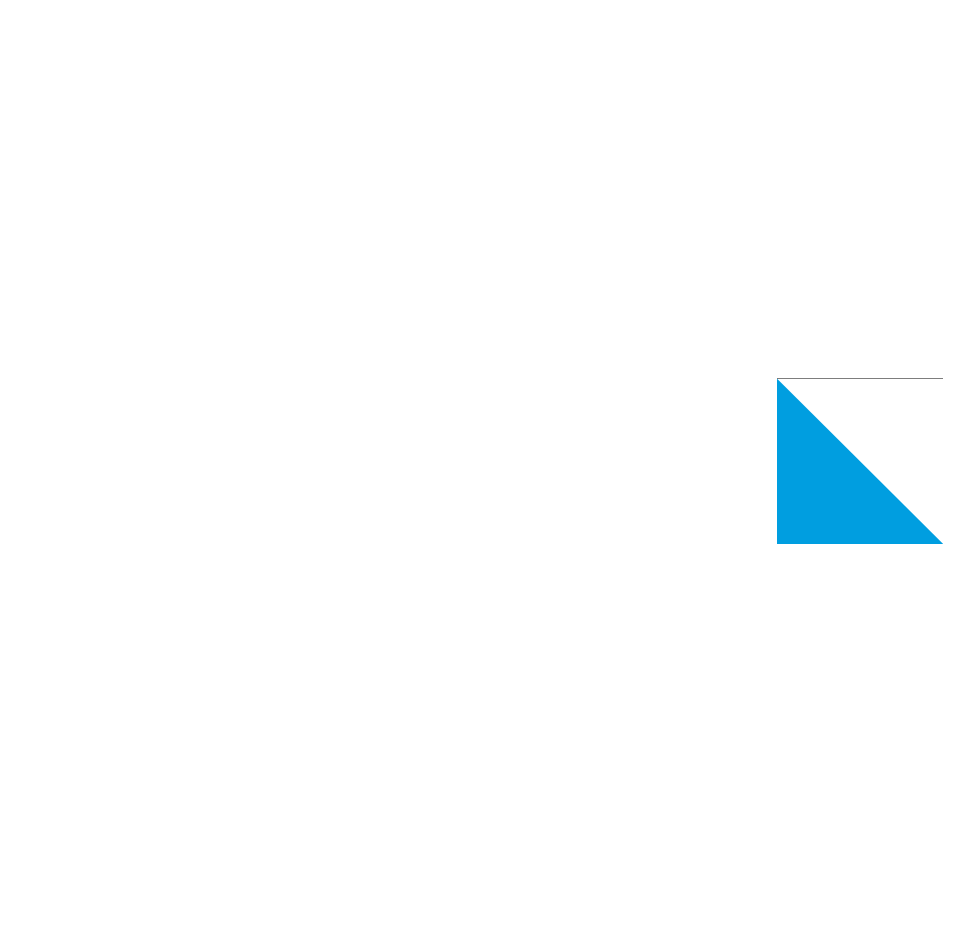

✅ UI rendered from http://localhost:3000
✅ Server ready for: anna_meier

🚀 Starting agent for anna_meier...

📂 Pre-reading all documents...
  📄 bank_statement.csv (csv, 1851 chars)
  📄 lohnausweis.txt (text, 1199 chars)
  📄 pillar_3a.txt (text, 571 chars)
  📄 profile.json (json, 390 chars)
  📄 zvv_receipt.txt (text, 345 chars)
✅ Pre-read 5 documents.

📚 Pre-loading tax guides...
✅ Loaded 11 guides: ['freelance-nebenberuf-steuern', 'homeoffice-fahrkosten-optimierung', 'kinderbetreuung-abzug-maximum', 'krankheitskosten-schwelle-5-prozent', 'krypto-steuern-privat-professionell', 'pensionierung-kapital-rente', 'policy_kb', 'quellensteuer-wechsel-ordentlich', 'scheidung-unterhalt-steuern', 'velo-pauschale-fahrkosten', 'verrechnungssteuer-rueckerstattung']
⚡ Auto-navigating to form...
  Navigated to: personal
🚀 Starting code-driven navigation...

--- Page 1: personal ---
  📝 23 fillable fields
  ❌ thought: Element not found
  ✅ field-personal-main-firstName = Anna
  ✅ field-personal-main-las

In [10]:
#@title 📊 anna_meier (click ▶ to run) { display-mode: "form" }

result = run_tax_agent(
    persona="anna_meier",
    port=PORT,
    client=client,
    think=think
)

print(result["score"])


🧑‍💼 Running persona: marco_laura_bernasconi



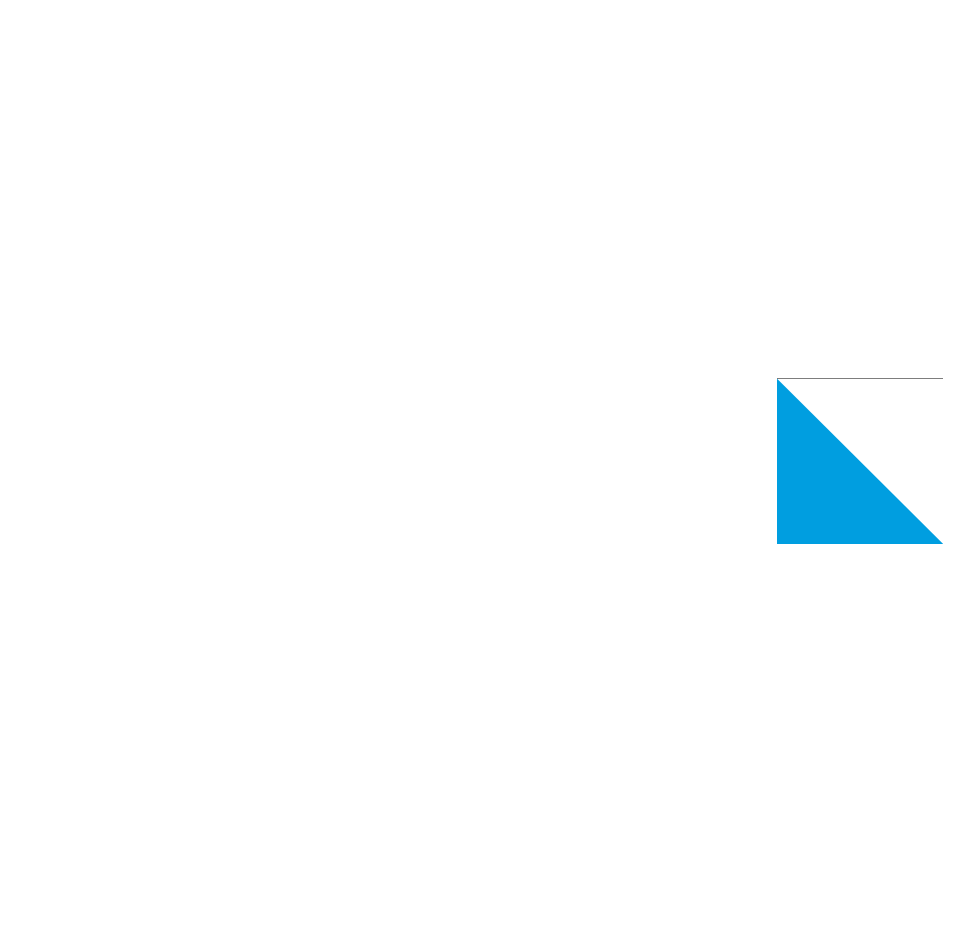

✅ UI rendered from http://localhost:3000
✅ Server ready for: marco_laura_bernasconi

🚀 Starting agent for marco_laura_bernasconi...

📂 Pre-reading all documents...
  📄 bank_statement_joint.csv (csv, 3181 chars)
  📄 kita_receipt.txt (text, 897 chars)
  📄 lohnausweis_laura.txt (text, 1218 chars)
  📄 lohnausweis_marco.txt (text, 1200 chars)
  📄 physiosuisse_membership.txt (text, 541 chars)
  📄 pillar_3a_laura.txt (text, 512 chars)
  📄 pillar_3a_marco.txt (text, 508 chars)
  📄 profile.json (json, 850 chars)
  📄 property_assessment.txt (text, 628 chars)
✅ Pre-read 9 documents.

📚 Pre-loading tax guides...
✅ Loaded 11 guides: ['freelance-nebenberuf-steuern', 'homeoffice-fahrkosten-optimierung', 'kinderbetreuung-abzug-maximum', 'krankheitskosten-schwelle-5-prozent', 'krypto-steuern-privat-professionell', 'pensionierung-kapital-rente', 'policy_kb', 'quellensteuer-wechsel-ordentlich', 'scheidung-unterhalt-steuern', 'velo-pauschale-fahrkosten', 'verrechnungssteuer-rueckerstattung']
⚡ Auto-naviga

In [11]:
#@title 📊 marco_laura_bernasconi (click ▶ to run) { display-mode: "form" }

result = run_tax_agent(
    persona="marco_laura_bernasconi",
    port=PORT,
    client=client,
    think=think
)

print(result["score"])

🧑‍💼 Running persona: priya_chakraborty



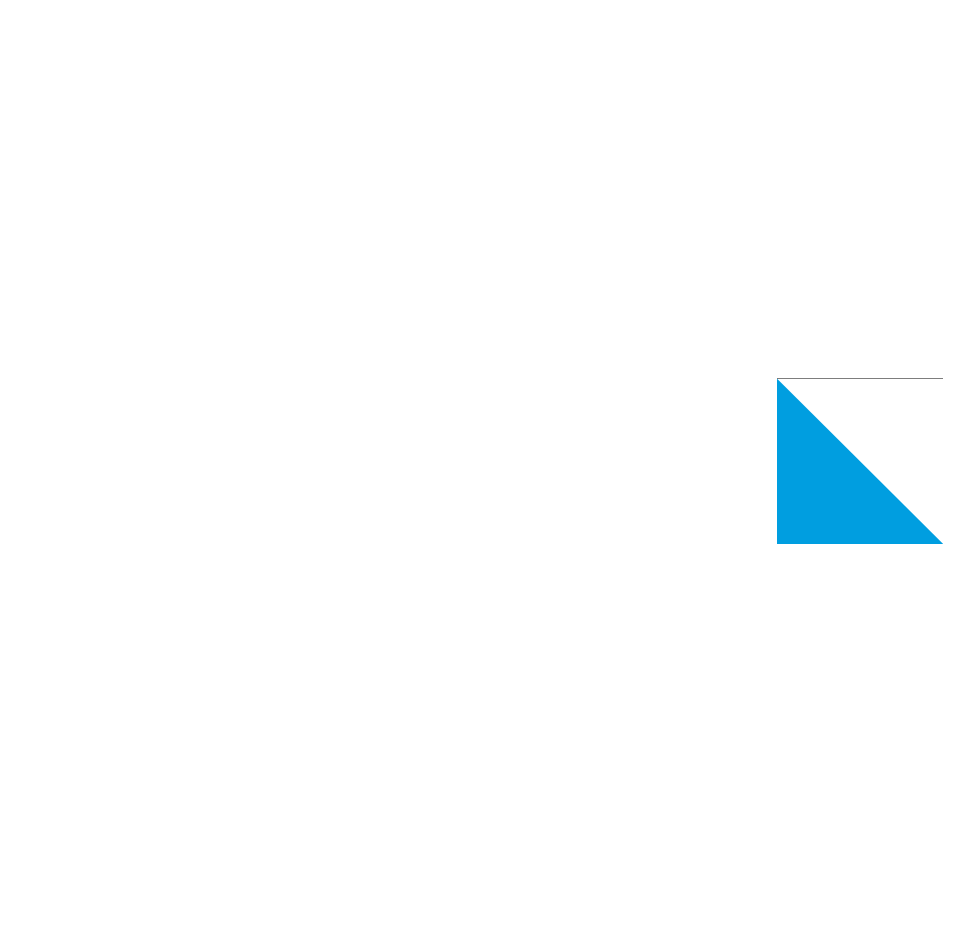

✅ UI rendered from http://localhost:3000
✅ Server ready for: priya_chakraborty

🚀 Starting agent for priya_chakraborty...

📂 Pre-reading all documents...
  📄 bank_statement.csv (csv, 2519 chars)
  📄 freelance_expenses.txt (text, 437 chars)
  📄 freelance_invoice_1.txt (text, 411 chars)
  📄 freelance_invoice_2.txt (text, 434 chars)
  📄 freelance_invoice_3.txt (text, 423 chars)
  📄 freelance_invoice_4.txt (text, 423 chars)
  📄 german_course_receipt.txt (text, 545 chars)
  📄 interactive_brokers_statement.txt (text, 2274 chars)
  📄 lohnausweis.txt (text, 1262 chars)
  📄 pillar_3a.txt (text, 530 chars)
  📄 profile.json (json, 598 chars)
✅ Pre-read 11 documents.

📚 Pre-loading tax guides...
✅ Loaded 11 guides: ['freelance-nebenberuf-steuern', 'homeoffice-fahrkosten-optimierung', 'kinderbetreuung-abzug-maximum', 'krankheitskosten-schwelle-5-prozent', 'krypto-steuern-privat-professionell', 'pensionierung-kapital-rente', 'policy_kb', 'quellensteuer-wechsel-ordentlich', 'scheidung-unterhalt-steue

In [12]:
#@title 📊 priya_chakraborty (click ▶ to run) { display-mode: "form" }

result = run_tax_agent(
    persona="priya_chakraborty",
    port=PORT,
    client=client,
    think=think
)

print(result["score"])

🧑‍💼 Running persona: thomas_elisabeth_widmer



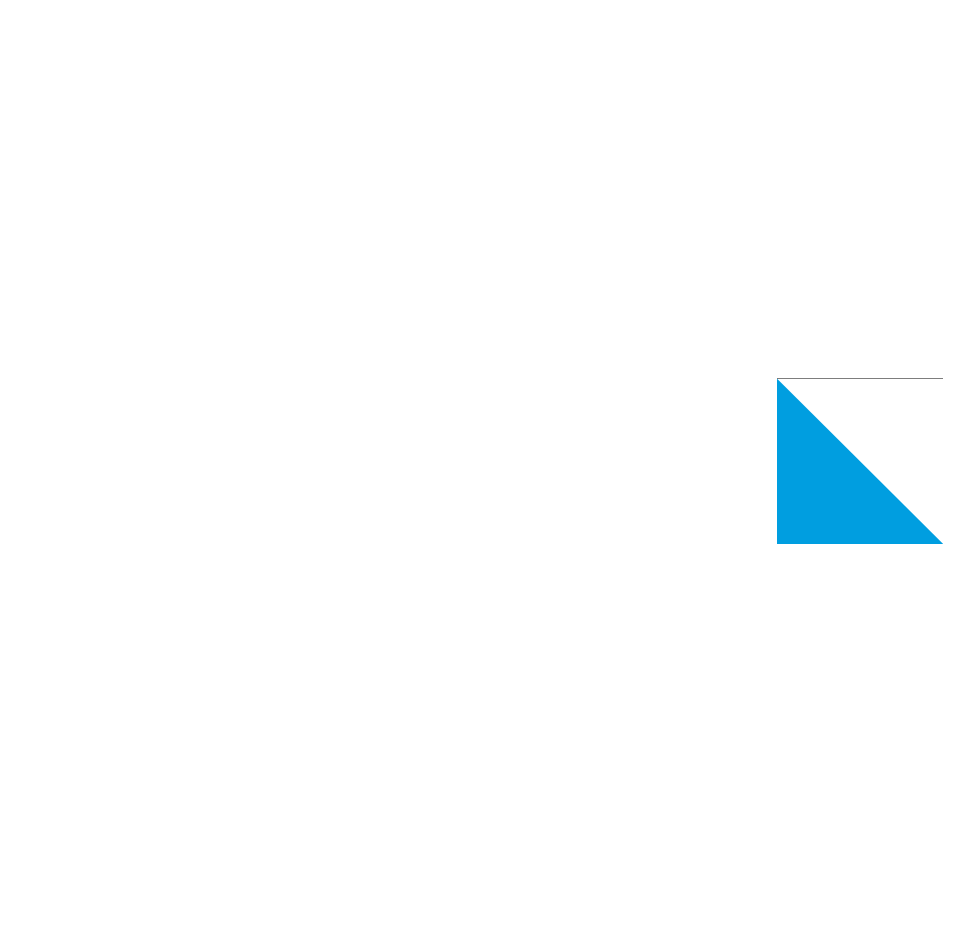

✅ UI rendered from http://localhost:3000
✅ Server ready for: thomas_elisabeth_widmer

🚀 Starting agent for thomas_elisabeth_widmer...

📂 Pre-reading all documents...
  📄 ahv_rentenbescheinigung_thomas.txt (text, 618 chars)
  📄 bank_statement.csv (csv, 2554 chars)
  📄 freizuegigkeitskonto_thomas.txt (text, 517 chars)
  📄 lohnausweis_elisabeth.txt (text, 1218 chars)
  📄 lohnausweis_thomas.txt (text, 1385 chars)
  📄 medical_receipts.txt (text, 775 chars)
  📄 pensionskasse_thomas.txt (text, 1065 chars)
  📄 pillar_3a_elisabeth.txt (text, 512 chars)
  📄 profile.json (json, 814 chars)
  📄 property_assessment.txt (text, 651 chars)
  📄 securities_portfolio.txt (text, 2634 chars)
✅ Pre-read 11 documents.

📚 Pre-loading tax guides...
✅ Loaded 11 guides: ['freelance-nebenberuf-steuern', 'homeoffice-fahrkosten-optimierung', 'kinderbetreuung-abzug-maximum', 'krankheitskosten-schwelle-5-prozent', 'krypto-steuern-privat-professionell', 'pensionierung-kapital-rente', 'policy_kb', 'quellensteuer-wechsel

In [13]:
#@title 📊 thomas_elisabeth_widmer (click ▶ to run) { display-mode: "form" }

result = run_tax_agent(
    persona="thomas_elisabeth_widmer",
    port=PORT,
    client=client,
    think=think
)

print(result["score"])

🧑‍💼 Running persona: yuki_tanaka



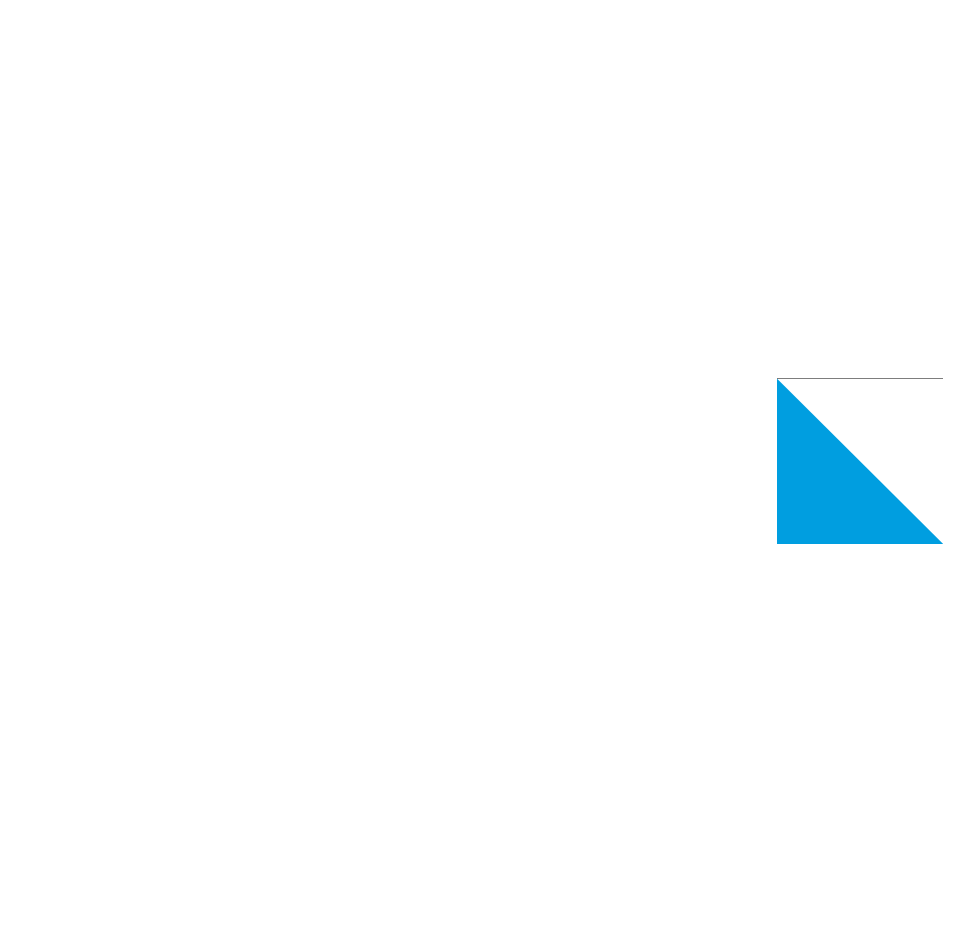

✅ UI rendered from http://localhost:3000
✅ Server ready for: yuki_tanaka

🚀 Starting agent for yuki_tanaka...

📂 Pre-reading all documents...
  📄 bank_statement.csv (csv, 2629 chars)
  📄 divorce_decree.txt (text, 1395 chars)
  📄 email_ex_husband.txt (text, 615 chars)
  📄 german_course_receipt.txt (text, 557 chars)
  📄 kita_receipt_blurry.txt (text, 643 chars)
  📄 lohnausweis.txt (text, 1209 chars)
  📄 profile.json (json, 854 chars)
✅ Pre-read 7 documents.

📚 Pre-loading tax guides...
✅ Loaded 11 guides: ['freelance-nebenberuf-steuern', 'homeoffice-fahrkosten-optimierung', 'kinderbetreuung-abzug-maximum', 'krankheitskosten-schwelle-5-prozent', 'krypto-steuern-privat-professionell', 'pensionierung-kapital-rente', 'policy_kb', 'quellensteuer-wechsel-ordentlich', 'scheidung-unterhalt-steuern', 'velo-pauschale-fahrkosten', 'verrechnungssteuer-rueckerstattung']
⚡ Auto-navigating to form...
  Navigated to: personal
🚀 Starting code-driven navigation...

--- Page 1: personal ---
  📝 23 fillable

In [14]:
#@title 📊 yuki_tanaka (click ▶ to run) { display-mode: "form" }

result = run_tax_agent(
    persona="yuki_tanaka",
    port=PORT,
    client=client,
    think=think
)

print(result["score"])

## 🤖 Bonus Task: Fully Agentic `think()`

So far your agent has been following a fixed path: your code drives the navigation, and the LLM only reasons about field values. That's the hybrid approach.

This bonus version goes further. Here, the LLM decides **everything**. Which tool to call, in what order, when to move to the next page, and when to submit. Your code just runs the loop and hands control to the model.

---

### Before you start 🙏

This approach is **significantly more expensive** in terms of API calls. The agent reads documents one by one, scans pages, fills fields, and navigates. Each action is a separate LLM call. A full run for Anna Meier can easily use 30–50 calls.

**Please only work on this after you have a working hybrid agent and a good score on your mandatory personas.** Don't burn your quota here before finishing the main task.

---

### How it works

The loop is simpler than it looks:

1. Build a message describing the current state (documents read, fields filled, last page scan)
2. Send it to the LLM with the system prompt. Then the LLM responds with `{"thought": "...", "tool": "...", "args": {...}}`
3. Execute the tool on the server
4. Feed the result back into the conversation
5. Repeat until the LLM calls `submit_form` or `done`

The LLM sees the full history of what it has done and reasons about what to do next. No hardcoded navigation, no page-specific logic, just a model in a loop with tools.

---

The system prompt `AGENT_SYSTEM_PROMPT` is already written for you. It tells the agent its workflow, its available tools, and the key Swiss tax rules it needs.

This task is not mandatory! It's here to give you a feel for what a fully agentic system looks like, and how it differs from the hybrid approach you already built.

In [15]:
#@title 🤖 Bonus — Fully Agentic think() { display-mode: "form" }

# import json
# import time
# import re

# AGENT_SYSTEM_PROMPT = """You are an expert Swiss tax accountant AI agent. Your job is to autonomously file a Zurich tax return (Steuererklärung 2025) for a taxpayer.

# ## Your workflow
# 1. First, call `list_documents` to see what files the taxpayer has.
# 2. Read each document with `read_document` to understand the taxpayer's situation.
# 3. Optionally call `list_guides` and `fetch_guide` to look up tax rules.
# 4. Call `scan_page` to see what fields are on the current form page.
# 5. Call `fill_field` for each field you want to fill.
# 6. Call `click_element` with locator "btn-next" to go to the next page.
# 7. Repeat steps 4-6 for each page.
# 8. When you reach the review page, call `submit_form`.

# ## Available tools
# - `list_documents` — no args. Returns list of filenames.
# - `read_document` — args: {"filepath": "filename.txt"}. Returns document content.
# - `list_guides` — no args. Returns available tax guide topics.
# - `fetch_guide` — args: {"url": "path/to/guide.html"}. Returns guide content.
# - `scan_page` — no args. Returns current page name, all fields (with locators, labels, values), and buttons.
# - `fill_field` — args: {"locator": "field-id", "value": "the value"}. Fills a form field.
# - `click_element` — args: {"locator": "button-id"}. Clicks a button.
# - `submit_form` — no args. Submits the completed tax return.
# - `ask_user` — args: {"question": "your question"}. Asks the taxpayer. USE SPARINGLY — penalised if the answer was in the documents.

# ## Navigation IDs
# - "btn-next" — the Next button on every form page
# - "tab-nav-form" — switches to the form view from overview
# - "btn-add-row-{section}-{table}" — adds a row to a dynamic table

# ## Response format
# You MUST respond with valid JSON and nothing else. No markdown, no explanation outside the JSON.
# ```json
# {
#   "thought": "Brief reasoning about what to do next and why",
#   "tool": "tool_name",
#   "args": {"key": "value"}
# }
# ```

# If you are done (after submitting), respond:
# ```json
# {"thought": "Tax return submitted successfully.", "tool": "done", "args": {}}
# ```

# ## Tax rules you should know
# - Lohnausweis field 1 = Bruttolohn (gross salary)
# - Lohnausweis field 9 = AHV/IV/EO contributions
# - Lohnausweis field 10 = BVG contributions
# - Lohnausweis field 13 = Spesen (already reimbursed — do NOT declare as income or deduction)
# - Lohnausweis field 14.1 = Kantinenverpflegung (canteen): "Ja" → meal deduction CHF 1,600; "Nein" → CHF 3,200
# - Berufsauslagen Pauschale = 3% of net salary (Bruttolohn - AHV - BVG), min CHF 2,000, max CHF 4,000
# - Pillar 3a maximum = CHF 7,056 (employed with pension fund)
# - Bank interest from "Zinsabschluss" entries = investment income
# - Donations found in bank statement (e.g., "Spende SRK") = deductible if ≥ CHF 100 total
# - Commuting: use ZVV receipt amount for Fahrkosten deduction
# - Bank balance on Dec 31 (last line of CSV) = wealth to declare

# ## Critical rules
# - Do NOT fill fields with "0", "None", or empty strings — leave irrelevant fields untouched.
# - Do NOT ask the user questions if the answer is in the documents.
# - When you scan a page, carefully read the field LABELS to understand what each field expects.
# - Only use locators you see in scan_page results — never guess field IDs.
# - After filling all fields on a page, click "btn-next" to proceed.
# - On the review page, call submit_form.
# """


# def parse_llm_response(text):
#     """Extract a JSON action from the LLM's response text."""
#     fence_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
#     if fence_match:
#         try:
#             return json.loads(fence_match.group(1))
#         except json.JSONDecodeError:
#             pass
#     brace_match = re.search(r'\{.*\}', text, re.DOTALL)
#     if brace_match:
#         try:
#             return json.loads(brace_match.group(0))
#         except json.JSONDecodeError:
#             pass
#     print(f"  [WARN] Could not parse LLM response, defaulting to scan_page")
#     return {"thought": "Could not parse response, scanning page.", "tool": "scan_page", "args": {}}


# def think(server, client, system_prompt=None, max_steps=80):
#     system_prompt = system_prompt or AGENT_SYSTEM_PROMPT
#     conversation_history = []
#     step = 0

#     documents_read      = []
#     guides_read         = []
#     questions_asked     = []
#     fields_filled       = {}
#     pages_visited       = []
#     has_listed_documents = False
#     has_listed_guides   = False
#     last_scan           = None

#     # ── The loop repeats until the agent submits or hits max_steps ──
#     while step < max_steps:
#         step += 1
#         print(f"\n{'='*50}")
#         print(f"Step {step}/{max_steps}")
#         print(f"{'='*50}")

#         # 🎯 Build the user message.
#         #    On the very first step, prompt the agent to call list_documents.
#         #    On all subsequent steps, summarise the current state:
#         #    what documents were read, what fields were filled, what the last scan showed.
#         if not has_listed_documents:
#             user_message = ...
#         else:
#             user_message = ...

#         conversation_history.append({"role": "user", "content": user_message})

#         # 🎯 Call the LLM — use the system prompt and the last 20 messages.
#         #    Include rate limit protection (time.sleep + retry on 429).
#         time.sleep(3)
#         for attempt in range(3):
#             try:
#                 response = ...
#                 break
#             except Exception as e:
#                 if '429' in str(e) and attempt < 2:
#                     print(f"  ⏳ Rate limited, waiting 30s...")
#                     time.sleep(30)
#                 else:
#                     raise

#         llm_text = response.choices[0].message.content
#         conversation_history.append({"role": "assistant", "content": llm_text})

#         # 🎯 Parse the LLM's response into an action dict — use parse_llm_response()
#         action = ...
#         thought = action.get("thought", "")
#         tool    = action.get("tool", "scan_page")
#         args    = action.get("args", {})

#         print(f"🧠 Thought: {thought}")
#         print(f"🔧 Tool:    {tool}({json.dumps(args)})")

#         # ── Handle terminal actions ──────────────────────────────
#         if tool == "done":
#             print("\n✅ Agent signaled done.")
#             return {"filled_history": fields_filled, "log": [], "submission": None}

#         if tool == "submit_form":
#             # 🎯 Call submit on the server and return the result
#             result = ...
#             print(f"\n📤 Submitted! Success: {result.get('success', False)}")
#             return {"filled_history": fields_filled, "log": [], "submission": result}

#         # 🎯 Execute the tool via server.execute() and handle errors gracefully.
#         #    If the tool raises an exception, append the error to conversation_history
#         #    and continue to the next step.
#         try:
#             result = ...
#         except Exception as e:
#             print(f"  ❌ Error: {e}")
#             result = {"error": str(e)}
#             conversation_history.append({
#                 "role": "user",
#                 "content": f"Tool error: {str(e)}\nPlease try a different action."
#             })
#             continue

#         result_str = json.dumps(result, indent=2, default=str)
#         if len(result_str) > 500:
#             print(f"  📋 Result: {result_str[:500]}...")
#         else:
#             print(f"  📋 Result: {result_str}")

#         # ── Update state tracking ────────────────────────────────
#         # 🎯 Update the state after every tool call so the next step has accurate context.
#         #    Each branch below tracks what happened — fill in the missing pieces:
#         #    mark documents/guides as read, record filled fields, update the page scan.

#         # 🎯
#         if tool == "...":
#             has_listed_documents = True
#         elif tool == "read_document":
#             # 🎯 Add the filepath to documents_read (avoid duplicates)
#             fp = ...
#         # 🎯
#         elif tool == "...":
#             has_listed_guides = True
#         elif tool == "...":
#             # 🎯 Add the guide url to guides_read (avoid duplicates)
#             url = ...
#         # 🎯
#         elif tool == "...":
#             # 🎯 Record the question that was asked
#             q = ...
#         # 🎯
#         elif tool == "...":
#             # 🎯 Store the result as last_scan and record the page name in pages_visited
#             last_scan = ...
#         # 🎯
#         elif tool == "...":
#             # 🎯 If the fill succeeded, store locator → value in fields_filled
#             if isinstance(result, dict) and result.get("success"):
#                 fields_filled[...] = ...
#         # 🎯
#         elif tool == "...":
#             if isinstance(result, dict) and result.get("new_page"):
#                 last_scan = None  # force a fresh scan on the new page

#         # 🎯 Feed the tool result back into conversation_history.
#         #    Truncate results longer than 6000 characters to protect the context window.
#         result_for_llm = ...
#         conversation_history.append({
#             "role": "user",
#             "content": f"Tool `{tool}` result:\n{result_for_llm}"
#         })

#     print(f"\n⚠️ Max steps ({max_steps}) reached without submitting.")
#     return {"filled_history": fields_filled, "log": [], "submission": None}